Libraries


In [56]:
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

Data Set Import


In [57]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Basic Info:

In [58]:
df.info()
df.describe()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Null Values

In [59]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Target value

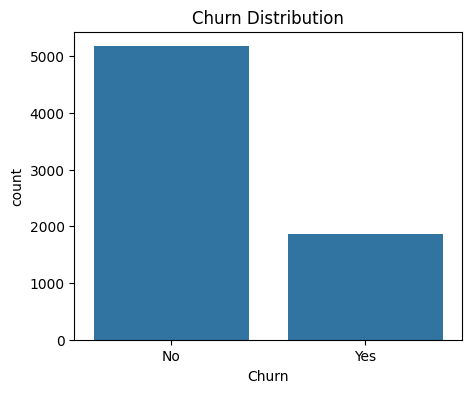

In [60]:
df['Churn'].value_counts()
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

Churn by Contract type

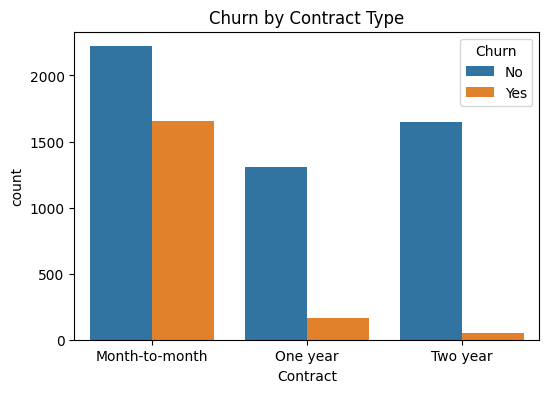

In [61]:
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

Churn by tenure & monthly charge

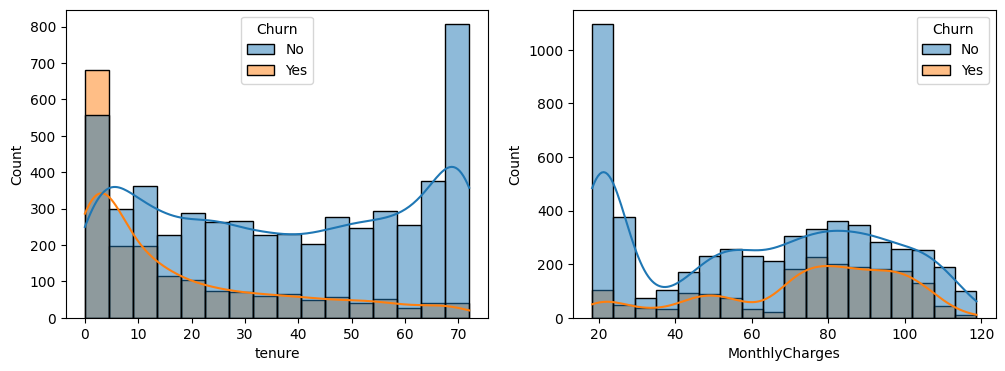

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, ax=axes[0])
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, ax=axes[1])
plt.show()

Drop Unwanted values

In [63]:
df.drop('customerID', axis=1 )
df = df.drop('customerID', axis=1)
print(df.shape)

(7043, 20)


Fix totalcharges columns

In [64]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()

np.int64(11)

Missing Values Handling

In [65]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].fillna(df['TotalCharges'].median()))


Target variable encode

In [66]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

One-Hot Encoding

In [67]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


Feature and Traget split

In [68]:
X = df_encoded.drop('Churn', axis=1)
Y = df_encoded['Churn']

print(X.shape, Y.shape)

(7043, 30) (7043,)


Feature Scaling

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
print(X_train.shape, X_test.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", Y_train.shape)
print("y_test:", Y_test.shape)

(5634, 30) (1409, 30)
X_train: (5634, 30)
X_test: (1409, 30)
y_train: (5634,)
y_test: (1409,)


LOGISTIC REGRESSION:

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, Y_train)
log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression:")
print("Accuracy:", accuracy_score(Y_test, log_pred))
print("Precision:", precision_score(Y_test, log_pred))
print("Recall:", recall_score(Y_test, log_pred))
print("F1 Score:", f1_score(Y_test, log_pred))


Logistic Regression:
Accuracy: 0.8069552874378992
Precision: 0.6583850931677019
Recall: 0.5668449197860963
F1 Score: 0.6091954022988506


KNN:

In [75]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, Y_train)
knn_pred = knn_model.predict(X_test_scaled)

print("K-Nearest Neighbors:")
print("Accuracy:", accuracy_score(Y_test, knn_pred))
print("Precision:", precision_score(Y_test, knn_pred))
print("Recall:", recall_score(Y_test, knn_pred))
print("F1 Score:", f1_score(Y_test, knn_pred))

K-Nearest Neighbors:
Accuracy: 0.7473385379701917
Precision: 0.5252808988764045
Recall: 0.5
F1 Score: 0.5123287671232877


DECISION TREE:

In [76]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, Y_train)
dt_pred = dt_model.predict(X_test)

print("Decision Tree:")
print("Accuracy:", accuracy_score(Y_test, dt_pred))
print("Precision:", precision_score(Y_test, dt_pred))
print("Recall:", recall_score(Y_test, dt_pred))
print("F1 Score:", f1_score(Y_test, dt_pred))

Decision Tree:
Accuracy: 0.7416607523066004
Precision: 0.5138888888888888
Recall: 0.4946524064171123
F1 Score: 0.5040871934604905


RANDOM FOREST:

In [77]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, Y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest:")
print("Accuracy:", accuracy_score(Y_test, rf_pred))
print("Precision:", precision_score(Y_test, rf_pred))
print("Recall:", recall_score(Y_test, rf_pred))
print("F1 Score:", f1_score(Y_test, rf_pred))

Random Forest:
Accuracy: 0.7863733144073811
Precision: 0.6237288135593221
Recall: 0.4919786096256685
F1 Score: 0.5500747384155455


VISULIZATION:

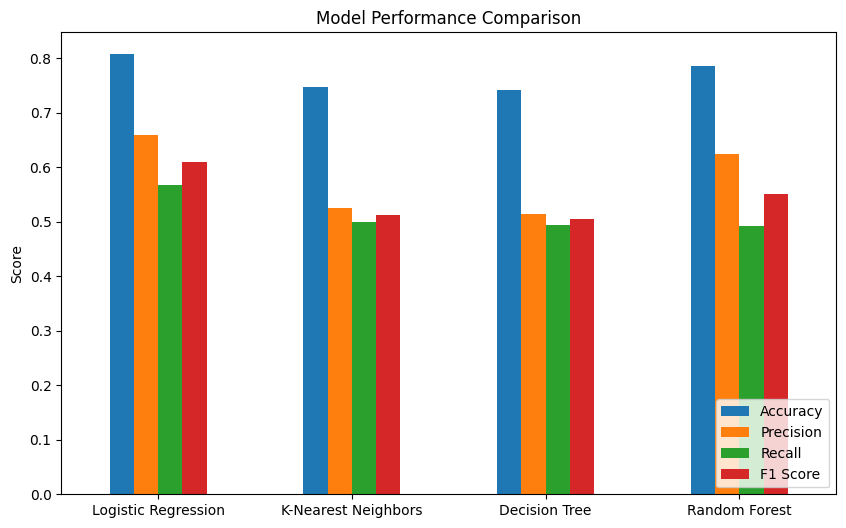

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
model_results = {
    "Logistic Regression": [0.8069552874378992, 0.6583850931677019, 0.5668449197860963, 0.6091954022988506],
    "K-Nearest Neighbors": [0.7473385379701917, 0.5252808988764045, 0.5, 0.5123287671232877],
    "Decision Tree": [0.7416607523066004, 0.5138888888888888, 0.4946524064171123, 0.5040871934604905],
    "Random Forest": [0.7863733144073811, 0.6237288135593221, 0.4919786096256685, 0.5500747384155455]
}

results_df = pd.DataFrame(model_results, index=['Accuracy', 'Precision', 'Recall', 'F1 Score']).T
results_df.plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

CONFUSION MATRIX

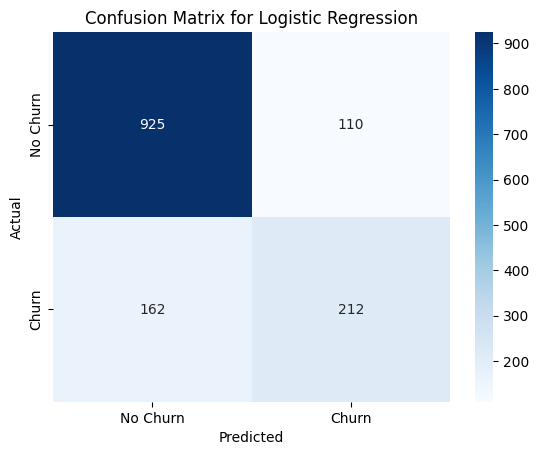

In [85]:
cm = confusion_matrix(Y_test, log_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [86]:
import joblib
joblib.dump(log_model, 'logistic_regression_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'model_columns.pkl')

['model_columns.pkl']

In [87]:
import sklearn
print(sklearn.__version__)

1.8.0
